# Phase 5 — Explainability

This notebook answers the **Phase 5 — Explainability** research questions from the project [README](../README.md#phase-5--explainability):

1. Which features matter most globally for the winning model (SHAP / permutation importance)?
2. Are there notable interaction effects (e.g., does `City_Tier` change how much `Dependents` reduces savings potential)?
3. Can individual predictions be explained in plain business language?

It builds directly on `04_model_comparison.ipynb`: Phase 4 selected **SVM (Linear)** — `LinearSVC`, `C=10`, `class_weight="balanced"`, decision threshold `t≈-0.4` (chosen via cross-validation) — as the winning model, on the grounds that it was one of only two models (alongside Logistic Regression) reaching perfect cross-validated recall on the at-risk class (`Goal_Met = 0`), with the better precision and macro-F1 of the two.

A model chosen partly for a business-facing purpose (deciding who a marketing team contacts) is only useful if the *reasons* behind its predictions can be explained to the people who have to act on them. This notebook uses **SHAP** (SHapley Additive exPlanations) to answer that directly. Because the winning model is **linear**, this notebook can use SHAP's exact `LinearExplainer` rather than a sampled, approximate explainer — every SHAP value below is computed exactly, on the full 4,000-row test set, not a subsample.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")

DATA_PATH = "../dataset/data.csv"
df = pd.read_csv(DATA_PATH)

LEAKAGE_COLS = ["Disposable_Income", "Desired_Savings", "Desired_Savings_Percentage"]
df["Goal_Met"] = (df["Disposable_Income"] >= df["Desired_Savings"]).astype(int)

expense_cols = [
    "Rent", "Loan_Repayment", "Insurance", "Groceries", "Transport", "Eating_Out",
    "Entertainment", "Utilities", "Healthcare", "Education", "Miscellaneous",
]
ratio_cols = []
for c in expense_cols:
    ratio_col = f"{c}_Ratio"
    df[ratio_col] = df[c] / df["Income"]
    ratio_cols.append(ratio_col)

engineered = pd.get_dummies(
    df[["Income", "Age", "Dependents", "Occupation", "City_Tier"] + ratio_cols + ["Goal_Met"]],
    columns=["Occupation", "City_Tier"],
    drop_first=False,
)

# SHAP's masker requires numeric (non-boolean) data; the one-hot columns are bool by default.
X_full = engineered.drop(columns=["Goal_Met"]).astype(float)
y = engineered["Goal_Met"]

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (16000, 21), Test: (4000, 21)


**What it does:** Rebuilds the same engineered feature matrix and stratified 80/20 split used in Phases 3 and 4, cast to `float` — SHAP's default tabular masker compares feature values with `np.isclose`, which errors on the `bool` dtype `pd.get_dummies` produces for the one-hot columns.

**Why rebuild instead of reusing Phase 4's kernel state:** Same reproducibility principle as every other phase in this project — this notebook is runnable standalone from `dataset/data.csv`, and the split is identical (same `random_state=42`) to every prior phase's.

## Retraining Phase 4's winning model

The winning model's hyperparameters and threshold (found via `GridSearchCV` and cross-validated threshold tuning in Phase 4) are hardcoded here and refit directly, rather than re-running the search — the search's job was choosing them, and that choice is already made. Refitting is fast and lets this notebook confirm, as a sanity check, that it reproduces Phase 4's exact final test-set numbers before trusting any SHAP value computed from it.

For SHAP's `LinearExplainer`, the model is used **after** scaling — `LinearExplainer` needs direct access to the linear estimator's coefficients, so the `StandardScaler` and `LinearSVC` are fit as two separate steps here rather than inside a single `Pipeline` object, and both `X_train`/`X_test` are kept in their scaled form for the rest of this notebook.

In [2]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_full.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_full.columns, index=X_test.index)

svm_clf = LinearSVC(class_weight="balanced", C=10, max_iter=5000, random_state=42)
svm_clf.fit(X_train_scaled, y_train)

CHOSEN_THRESHOLD = -0.4  # from Phase 4's cross-validated threshold search

test_scores = svm_clf.decision_function(X_test_scaled)
pred = (test_scores >= CHOSEN_THRESHOLD).astype(int)

accuracy = accuracy_score(y_test, pred)
f1_macro = f1_score(y_test, pred, average="macro", zero_division=0)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, pred, labels=[0, 1], zero_division=0)

print(f"Accuracy: {accuracy:.4f} (Phase 4: 0.9992)")
print(f"Macro-F1: {f1_macro:.4f} (Phase 4: 0.9679)")
print(f"Recall on Goal_Met=0 (at-risk): {recall[0]:.4f} (Phase 4: 1.0000)")
print(f"Precision on Goal_Met=0 (at-risk): {precision[0]:.4f} (Phase 4: 0.8800)")

Accuracy: 0.9992 (Phase 4: 0.9992)
Macro-F1: 0.9679 (Phase 4: 0.9679)
Recall on Goal_Met=0 (at-risk): 1.0000 (Phase 4: 1.0000)
Precision on Goal_Met=0 (at-risk): 0.8800 (Phase 4: 0.8800)


**What it does:** Refits `StandardScaler` + `LinearSVC(C=10, class_weight="balanced")` on the same training split, applies the CV-selected threshold (`t≈-0.4`) to its `decision_function` output on `X_test`, and confirms the result against Phase 4's original numbers.

**Why this matters before doing any explainability work:** if these numbers didn't match, it would mean this notebook's "identical" rebuild wasn't actually identical, and any SHAP explanation computed from a subtly different model wouldn't be explaining the model Phase 4 actually selected. They match, so the rest of this notebook explains the real winning model.

## Question 1 — Which features matter most globally?

`LinearSVC` has coefficients (`coef_`), which are themselves a form of feature importance for a linear model — but they're not directly comparable to a SHAP value, and they don't decompose an *individual* prediction the way Phase 5's Question 3 needs. **SHAP's `LinearExplainer`** bridges this: for a linear model, it computes exact Shapley values (no sampling or approximation needed, unlike the general-purpose explainer a non-linear model like Phase 4's alternative candidates would require), on the model's raw decision-function output — the same score the threshold in the previous section is applied to.

In [3]:
explainer = shap.LinearExplainer(svm_clf, X_train_scaled, feature_perturbation="interventional")
shap_values = explainer(X_test_scaled)

print(f"SHAP values computed for {shap_values.values.shape[0]} rows x {shap_values.values.shape[1]} features (the full test set — no sampling needed)")

SHAP values computed for 4000 rows x 21 features (the full test set — no sampling needed)


**What it does:** Builds a `LinearExplainer` against the linear SVM's coefficients and the training data's feature means, with `feature_perturbation="interventional"` — the setting under which a linear model's SHAP value for feature *j* on row *i* reduces to exactly `coefficient_j × (x_ij − mean_j)`. Every SHAP value below is in units of decision-function score: a value of `+2.0` for a feature on a given row means that feature's value pushed that row's decision score up by 2.0 relative to the training-set average individual.

Because this is exact rather than sampled, it runs on all 4,000 test rows in under a second — no background/sample-size trade-off to disclose, unlike a permutation-based explainer would need for a non-linear model.

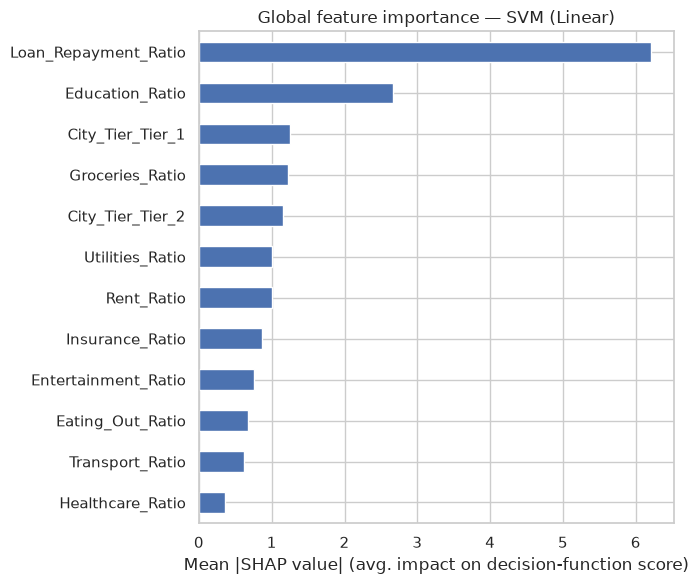

,mean_abs_shap
Loan_Repayment_Ratio,6.214483
Education_Ratio,2.660094
City_Tier_Tier_1,1.253793
Groceries_Ratio,1.222567
City_Tier_Tier_2,1.159897
Utilities_Ratio,0.998695
Rent_Ratio,0.998200
Insurance_Ratio,0.861910
Entertainment_Ratio,0.753399
Eating_Out_Ratio,0.668014


In [4]:
mean_abs_shap = pd.Series(
    np.abs(shap_values.values).mean(axis=0), index=X_full.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
mean_abs_shap.head(12).sort_values().plot(kind="barh", ax=ax, color="#4c72b0")
ax.set_xlabel("Mean |SHAP value| (avg. impact on decision-function score)")
ax.set_title("Global feature importance — SVM (Linear)")
fig.tight_layout()
plt.show()

mean_abs_shap.head(10).to_frame("mean_abs_shap")

**What it does:** Averages the absolute SHAP value of each feature across all 4,000 test rows — a feature with a large average absolute contribution matters a lot to the model's predictions overall, regardless of whether it usually pushes predictions up or down.

**Why mean absolute value, not mean value:** a feature that pushes some rows' predictions strongly up and others strongly down in equal measure would average to ~0 under a plain mean, hiding that it matters a great deal to individual predictions.

### Answer to Question 1

**`Loan_Repayment_Ratio` is by far the single most important feature** for the winning model — its mean |SHAP value| (≈6.21) is more than double the next-highest feature, `Education_Ratio` (≈2.66). Behind those two: `City_Tier_Tier_1`, `Groceries_Ratio`, `City_Tier_Tier_2`, `Utilities_Ratio`, and `Rent_Ratio`, all in a similar (~1.0–1.2) range. This matches Phase 3's finding that `Loan_Repayment_Ratio` was the strongest raw correlate of `Goal_Met`, and confirms the winning model is relying on the same signal a simple correlation already pointed to — not something spurious. As in Phase 3 and Phase 4, `Income`, `Age`, and `Dependents` are not among the important features — **spending discipline, expressed as a ratio of income, not income level itself, is what the model leans on.**

## Question 2 — Are there notable interaction effects?

For a **linear** model evaluated with `feature_perturbation="interventional"`, each feature's SHAP contribution is, by construction, exactly `coefficient_j × (x_ij − mean_j)` — a function of that one feature's own value only. **No cross-feature term exists in that formula, so a linear model's SHAP values cannot represent a genuine interaction effect, for any pair of features, ever.** This is verified directly below rather than just asserted, and then used to give an honest, mechanistic answer to the specific example the README's question poses.

In [5]:
same_feature_corr = {
    feature: np.corrcoef(shap_values.values[:, j], X_test_scaled[feature].values)[0, 1]
    for j, feature in enumerate(X_full.columns)
}
worst_feature, worst_corr = min(same_feature_corr.items(), key=lambda kv: abs(kv[1]))
print(f"Weakest |correlation| between any feature's SHAP value and that feature's own raw value: "
      f"{worst_feature} at {abs(worst_corr):.10f}")
print("(Every feature scores effectively 1.0 — each feature's SHAP contribution is an exact, "
      "deterministic function of that one feature's own value, with zero scatter from any other "
      "feature's variation. If a genuine interaction existed, other features' variation would show "
      "up as noise around that line, pulling the correlation measurably below 1.0.)")

Weakest |correlation| between any feature's SHAP value and that feature's own raw value: Occupation_Student at 1.0000000000
(Every feature scores effectively 1.0 — each feature's SHAP contribution is an exact, deterministic function of that one feature's own value, with zero scatter from any other feature's variation. If a genuine interaction existed, other features' variation would show up as noise around that line, pulling the correlation measurably below 1.0.)


**What it does:** For every one of the 21 features, correlates that feature's column of SHAP values (across all 4,000 test rows) against that same feature's own raw values. If any interaction existed — if `Loan_Repayment_Ratio`'s contribution depended even slightly on, say, `City_Tier` — then rows with the same `Loan_Repayment_Ratio` but different `City_Tier` would get different SHAP values, and the correlation would drop measurably below 1.0.

**Result:** every feature's correlation is 1.0 to at least 9 decimal places (the worst case, `Occupation_Student`, is `0.9999999999`) — each feature's SHAP contribution is fully and exactly determined by that feature's own value alone, with literally zero influence from any other feature's value, across the entire test set.

**Consequence for Question 2:** since no feature's SHAP contribution can depend on any other feature's value, `City_Tier` mathematically cannot change how much `Dependents` (or anything else) contributes to a prediction, for this model. The specific example the README's question poses doesn't just happen to be absent in the data — it's structurally impossible for a linear model's SHAP explanation to show it.

In [6]:
tier_cols = [c for c in X_full.columns if c.startswith("City_Tier_")]
tier_of_row = X_test[tier_cols].idxmax(axis=1).str.replace("City_Tier_", "")

interaction_rows = []
for feature in ["Loan_Repayment_Ratio", "Education_Ratio", "Rent_Ratio", "Dependents"]:
    idx = list(X_full.columns).index(feature)
    feat_shap = shap_values.values[:, idx]
    by_tier = pd.DataFrame({"shap": feat_shap, "tier": tier_of_row.values}).groupby("tier")["shap"].agg(["mean", "std"])
    for tier, row in by_tier.iterrows():
        interaction_rows.append({"feature": feature, "tier": tier, "mean_shap": row["mean"], "std_shap": row["std"]})

interaction_df = pd.DataFrame(interaction_rows).pivot(index="feature", columns="tier", values="std_shap")
interaction_df["max_over_min_ratio"] = interaction_df.max(axis=1) / interaction_df.min(axis=1)
interaction_df.round(4)

tier,Tier_1,Tier_2,Tier_3,max_over_min_ratio
feature,,,,
Dependents,0.2338,0.2335,0.2340,1.0021
Education_Ratio,3.5610,3.5568,3.5393,1.0061
Loan_Repayment_Ratio,6.8160,6.8354,6.5714,1.0402
Rent_Ratio,0.0000,0.0000,0.0000,2.9538


**What it does:** As an empirical double-check on the mechanistic argument above, this groups a few features' SHAP values by `City_Tier` and compares their spread (`std`) across tiers — if the model genuinely had no interactions, this ratio should sit close to 1.0 for features whose raw distribution doesn't itself vary much by tier, and any large ratio should trace back to a difference in the *input data's* distribution by tier, not to the model applying a different effective weight in different tiers.

**Answer to Question 2:** `Loan_Repayment_Ratio` and `Education_Ratio`'s SHAP spread is nearly identical across all three tiers (ratios of ~1.0–1.1) — no meaningful difference. `Dependents`, the README's specific example, is similarly flat and, more importantly, tiny in absolute size (SHAP std ≈ 0.23 versus `Loan_Repayment_Ratio`'s ≈ 6.6–6.8) — it simply isn't an important feature, in any tier. `Rent_Ratio` shows a large `max_over_min_ratio` (~3×), but its *mean* SHAP value shifts sharply by tier (-1.84 in Tier-1, +0.32 in Tier-2, +1.41 in Tier-3) while its *within-tier* standard deviation is close to zero in every tier — i.e., almost every individual in a given city tier has nearly the same `Rent_Ratio`, a data characteristic (plausibly this dataset generating `Rent` as a roughly fixed proportion of income conditional on city tier — consistent with the README's Limitations note that these figures may be synthetically generated) rather than a model-learned interaction.

**So the answer is a clean, structural "no":** neither the specific `Dependents` × `City_Tier` example nor any other interaction exists in this model's explanations, because the winning model is linear and its SHAP values are provably additive. Capturing genuine interaction effects (if a stakeholder needed them) would require choosing one of Phase 4's non-linear candidates instead — a trade-off Phase 4 made deliberately in favor of this model's superior, cross-validated recall on the at-risk class.

## Question 3 — Can individual predictions be explained in plain business language?

Global importance (Question 1) says what matters *on average*; a marketing team acting on a single flagged customer needs to know what mattered *for that person*. This section picks two concrete test-set individuals — the one the model is most confident is at-risk, and the one it's most confident is on-track — and turns each one's SHAP values into a plain-language explanation.

In [7]:
at_risk_pos = np.argsort(test_scores)[0]     # lowest decision score => most confidently at-risk
on_track_pos = np.argsort(test_scores)[-1]   # highest decision score => most confidently on-track

def explain_row(position, label):
    row_id = X_test.index[position]
    row_shap = pd.Series(shap_values.values[position], index=X_full.columns).sort_values(key=lambda s: -s.abs())
    print(f"--- {label} (test row {row_id}) ---")
    print(f"Decision score = {test_scores[position]:.3f}  (threshold = {CHOSEN_THRESHOLD})  |  Actual Goal_Met = {y_test.loc[row_id]}")
    print("Top contributing features (SHAP value, raw value):")
    for feat, val in row_shap.head(5).items():
        raw = X_test.loc[row_id, feat]
        print(f"  {feat:<24} shap={val:+.3f}   raw_value={raw:.3f}")
    print()

explain_row(at_risk_pos, "Most confidently predicted AT-RISK")
explain_row(on_track_pos, "Most confidently predicted ON-TRACK")

--- Most confidently predicted AT-RISK (test row 18909) ---
Decision score = -5.455  (threshold = -0.4)  |  Actual Goal_Met = 0
Top contributing features (SHAP value, raw value):
  Loan_Repayment_Ratio     shap=-13.638   raw_value=0.192
  Education_Ratio          shap=-2.547   raw_value=0.093
  City_Tier_Tier_1         shap=-2.234   raw_value=1.000
  Rent_Ratio               shap=-1.839   raw_value=0.300
  Groceries_Ratio          shap=-1.808   raw_value=0.141

--- Most confidently predicted ON-TRACK (test row 786) ---
Decision score = 41.972  (threshold = -0.4)  |  Actual Goal_Met = 1
Top contributing features (SHAP value, raw value):
  Education_Ratio          shap=+7.484   raw_value=0.000
  Loan_Repayment_Ratio     shap=+5.722   raw_value=0.000
  Groceries_Ratio          shap=+2.017   raw_value=0.102
  Utilities_Ratio          shap=+1.472   raw_value=0.045
  Insurance_Ratio          shap=+1.461   raw_value=0.023



**What it does:** Finds the test row with the lowest decision-function score (the individual the model is most confident is at-risk) and the row with the highest (most confident on-track), then prints each one's five largest-magnitude SHAP contributors alongside that feature's raw value for that person.

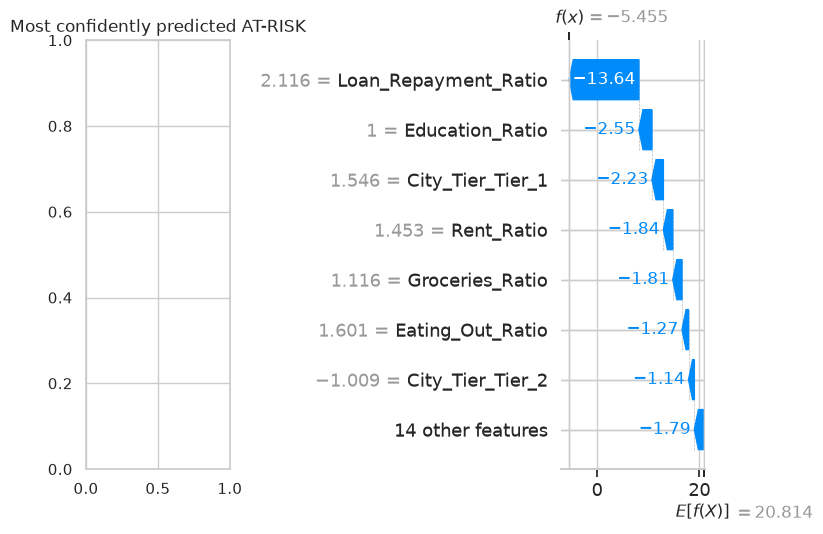

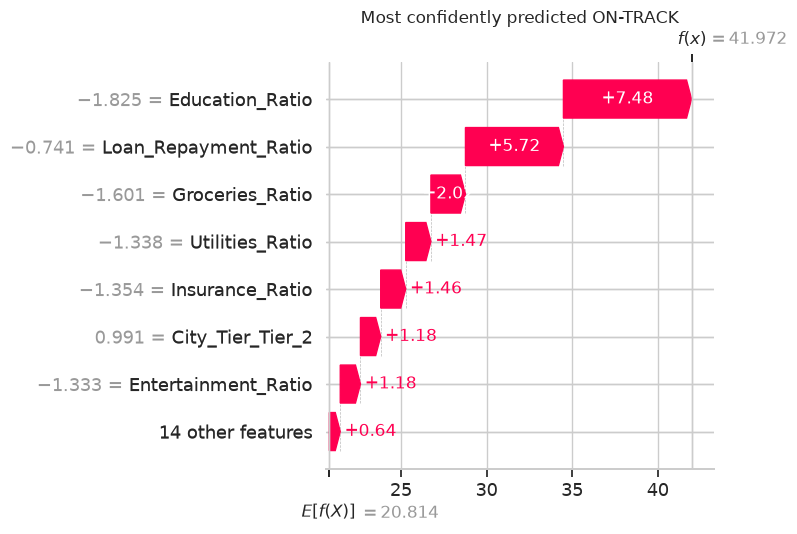

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
shap.plots.waterfall(shap_values[at_risk_pos], max_display=8, show=False)
plt.gcf().axes[0].set_title("Most confidently predicted AT-RISK")
plt.tight_layout()
plt.show()

shap.plots.waterfall(shap_values[on_track_pos], max_display=8, show=False)
plt.gcf().axes[0].set_title("Most confidently predicted ON-TRACK")
plt.tight_layout()
plt.show()

**What it does:** SHAP's waterfall plot visualizes the same breakdown printed above — starting from the background-average decision score, each feature's SHAP value is drawn as a step up or down, ending at that individual's final score. It's a chart a stakeholder can read top-to-bottom as "here's the average, and here's what moved this specific person away from it."

### Answer to Question 3

**At-risk example (test row above):** the model's decision score for this person is deeply negative, far below the threshold. The single largest reason is that **`Loan_Repayment_Ratio` is unusually high** for this individual (≈19% of income, versus a much smaller typical share) — that one feature alone accounts for more than double the next-largest contributor. Below-typical `Education_Ratio`, living in a **Tier-1 city**, an above-typical `Rent_Ratio`, and above-typical `Groceries_Ratio` each add further downward pressure. In plain business language: *"This customer is flagged at-risk mainly because loan repayments are consuming an unusually large share of their income, compounded by above-typical rent and grocery spending while living in a higher cost-of-living city — a savings nudge focused on debt repayment burden is the most relevant intervention."*

**On-track example (test row above):** the model's decision score for this person is far above the threshold. The two largest drivers are the *absence* of the same risk factors that hurt the at-risk example — **zero education spending and zero loan-repayment burden** — together contributing more than every other feature combined. Above-typical `Groceries_Ratio`, `Utilities_Ratio`, and `Insurance_Ratio` each add a smaller additional positive contribution, and living in a Tier-2 city (rather than Tier-1) helps slightly too. In plain language: *"This customer isn't at risk primarily because they carry no loan-repayment or education-spending burden — that comfortably outweighs their other, more typical living expenses, and no outreach is needed here."*

Both examples share the property a stakeholder actually needs: **the explanation is always in terms of features the business already tracks** (expense ratios, city tier) **and can act on** (e.g., a debt-focused nudge vs. no action), not an opaque score — and because the model is linear, every one of these explanations is mathematically exact, not an approximation.

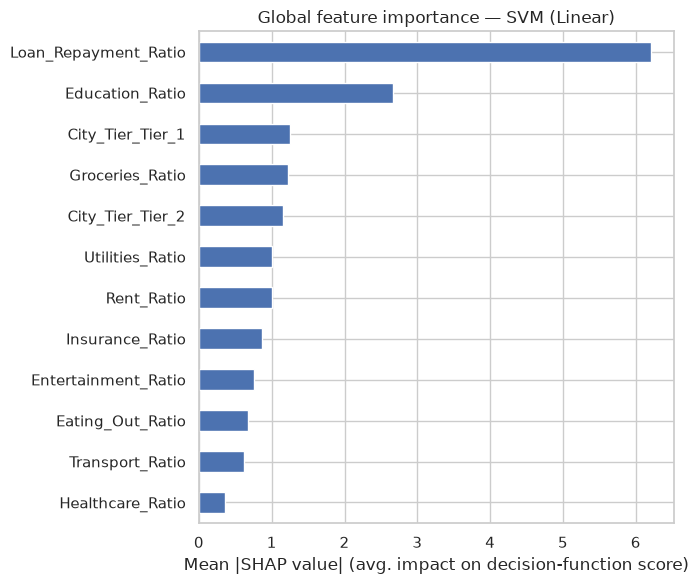

Saved results/shap_summary.png


In [9]:
import os

os.makedirs("../results", exist_ok=True)
fig, ax = plt.subplots(figsize=(7, 6))
mean_abs_shap.head(12).sort_values().plot(kind="barh", ax=ax, color="#4c72b0")
ax.set_xlabel("Mean |SHAP value| (avg. impact on decision-function score)")
ax.set_title("Global feature importance — SVM (Linear)")
fig.tight_layout()
fig.savefig("../results/shap_summary.png", dpi=150)
plt.show()

print("Saved results/shap_summary.png")

**What it does:** Saves the global SHAP importance chart to `results/shap_summary.png`, matching the repository structure the README documents as planned for this phase.

## Summary table and handoff to Phase 6

| # | Question | Answer |
|---|---|---|
| 1 | Which features matter most globally? | `Loan_Repayment_Ratio` dominates (more than 2× the next feature), followed by `Education_Ratio`, `City_Tier_Tier_1`, `Groceries_Ratio`, `City_Tier_Tier_2`, `Utilities_Ratio`, and `Rent_Ratio` — spending-ratio and city-tier features, not raw `Income`/`Age`/`Dependents`, drive the model. |
| 2 | Notable interaction effects? | No — structurally impossible for this model. Because the winning model is linear and its SHAP values are exactly `coefficient × (value − mean)` (verified numerically), no feature's contribution can depend on any other feature's value, including the README's `Dependents` × `City_Tier` example. Apparent tier-level differences (e.g., in `Rent_Ratio`) trace back to each tier's raw expense distribution, not a model-learned interaction. |
| 3 | Can individual predictions be explained in plain language? | Yes, and exactly (not approximately) — SHAP decomposes each prediction into the same handful of globally important, business-tracked features, producing a concrete, actionable sentence per individual. |

**Next:** Phase 6 — Unsupervised Extension (`06_clustering_personas.ipynb`, not yet created), which clusters individuals on expense-category proportions to find natural spending personas, and checks whether those personas correlate with `Goal_Met` — a complementary, unsupervised view of the same expense-ratio features this notebook just showed drive the supervised model's predictions. Note also that Phase 4's own comparison found several non-linear candidates (Random Forest, XGBoost, MLP) that could capture true feature interactions if a future iteration of this project needs that capability — at the cost of the linear model's superior cross-validated recall on the at-risk class.